In [4]:
%load_ext autoreload
%autoreload 2
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import behavior
import pickle
import dill
import numpy as np
import os 
import matplotlib.pyplot as plt
import TwoPUtils
import protter_functions as pf
from scipy.signal import medfilt
from matplotlib.lines import Line2D
import pandas as pd
import umap
import hdbscan
import importlib

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
licks_na_free = np.load('protter_tmp_files/all_licks_na_dropped.npy')
trials_na_free = pd.read_csv('protter_tmp_files/new_all_licks_na_dropped_trial_info.csv')

In [6]:
def get_reward_zone_outliers(cluster_column_name, value, meta):

    meta_slice = meta.loc[meta[cluster_column_name] == value]

    rzones = meta_slice['reward_zone_start'].value_counts()
    
    if len(rzones)>1:
        return meta_slice
    else:
        return None
    
# outliers = {}
# for animal in trials_na_free.animal.unique():

    
#     for day in trials_na_free.day.unique():
#         ani_slice = trials_na_free.loc[(trials_na_free.animal == animal)&(trials_na_free.day == day)]
#         for i in range( trials_na_free.hdb_labels.max()+1 ):
#             out = get_reward_zone_outliers('hdb_labels', i, ani_slice)
#             if not out is None:
#                 if animal in outliers.keys() and day in outliers[animal].keys():

#                     outliers[animal][day][i] = out
#                 elif animal in outliers.keys():
#                     outliers[animal][day] = {i:out}
#                 else:
#                     outliers[animal] = {day:{i:out}}

# for animal in outliers.keys():
#     print(f'------ {animal}')
#     for day in outliers[animal].keys():
#         print(f'----------- {day}')
#         for label in outliers[animal][day].keys():
#             print(f'------------------ {label}: {len(outliers[animal][day][label])}')

In [8]:
from sklearn import decomposition as skd

lick_pca = skd.PCA()
transform = lick_pca.fit_transform(licks_na_free)

In [9]:
transform.shape

(6222, 45)

pct_total = [sum(lick_pca.explained_variance_[:i+1]/lick_pca.explained_variance_.sum()) for i in range(transform.shape[1])]
lick_pca.explained_variance_/lick_pca.explained_variance_.sum()
fig, ax = plt.subplots()
ax.plot(pct_total, 'o')

In [10]:
trials_na_free

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal
0,0,0,3,0,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
1,1,1,3,1,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
2,2,2,3,2,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
3,3,3,3,3,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
4,4,4,3,4,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
...,...,...,...,...,...,...,...,...,...,...,...,...
6217,75,6280,14,75,80,130,320.0,370.0,post_swap,swap_proximal,False,GCAMP19
6218,76,6281,14,76,80,130,320.0,370.0,post_swap,swap_proximal,True,GCAMP19
6219,77,6282,14,77,80,130,320.0,370.0,post_swap,swap_proximal,True,GCAMP19
6220,78,6283,14,78,80,130,320.0,370.0,post_swap,swap_proximal,False,GCAMP19


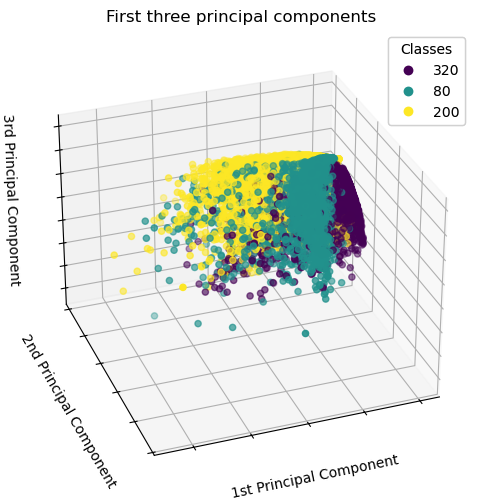

In [11]:
import mpl_toolkits.mplot3d 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)
scatter = ax.scatter(
    transform[:, 0],
    transform[:, 1],
    transform[:, 2],
    c=trials_na_free.reward_zone_start,
   
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    trials_na_free.reward_zone_start.unique().tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

In [12]:
def get_licks_at_location(licks, loc, bins):
    '''loc = [start, end]'''
    st, en = np.searchsorted(bins, loc)
    return {'licks':licks[:,st:en], 'bin_centers':bins[st:en]}


In [13]:
def get_lick_features(licks, bins_centers,  meta, norm = True):
    ''''''
    n_licks = licks.sum(axis = 1)

    rzone_1_start = meta.reward_zone_start.values[0]
    rzone_2_start = meta.reward_zone_start.values[-1]
    

    rzone_1_end = meta.reward_zone_end.values[0]
    rzone_2_end = meta.reward_zone_end.values[-1]

    rzone_1 = [rzone_1_start, rzone_1_end]
    rzone_2 = [rzone_2_start, rzone_2_end]

    rzone_1_trials = meta.reward_zone_start == rzone_1_start
    rzone_2_trials = meta.reward_zone_start == rzone_2_start
    

    at_zone = np.zeros_like(n_licks)
    at_other_zone = np.zeros_like(n_licks)
    after_zone = np.zeros_like(n_licks)
    after_other_zone = np.zeros_like(n_licks)
    before_zone = np.zeros_like(n_licks)
    before_other_zone = np.zeros_like(n_licks)

    
    at_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], rzone_1, bin_centers)['licks'].sum(axis = 1)
    at_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], rzone_2, bin_centers)['licks'].sum(axis = 1)

    at_other_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], rzone_2, bin_centers)['licks'].sum(axis = 1)
    at_other_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], rzone_1, bin_centers)['licks'].sum(axis = 1)

    after_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], [rzone_1_end, rzone_1_end + 30], bin_centers)['licks'].sum(axis = 1)
    after_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], [rzone_2_end, rzone_2_end + 30], bin_centers)['licks'].sum(axis = 1)

    after_other_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], [rzone_2_end, rzone_2_end + 30], bin_centers)['licks'].sum(axis = 1)
    after_other_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], [rzone_1_end, rzone_1_end + 30], bin_centers)['licks'].sum(axis = 1)

    before_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], [rzone_1_start - 50, rzone_1_start], bin_centers)['licks'].sum(axis = 1)
    before_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], [rzone_2_start - 50, rzone_2_start], bin_centers)['licks'].sum(axis = 1)

    before_other_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], [rzone_2_start - 50, rzone_2_start], bin_centers)['licks'].sum(axis = 1)
    before_other_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], [rzone_1_start - 50, rzone_1_start], bin_centers)['licks'].sum(axis = 1)

    feature_set = [n_licks, at_zone/n_licks, at_other_zone/n_licks, after_zone/n_licks, after_other_zone/n_licks, before_zone/n_licks, before_other_zone/n_licks]

    if norm:
        feature_norm = [feat/n_licks for feat in feature_set[1:]]
        feature_set = [n_licks]+feature_norm     
   
    feature_arr = np.zeros((len(licks), len(feature_set)))
    for i, feat in enumerate(feature_set):
        feature_arr[:,i] = feat

    
    return np.nan_to_num(feature_arr)



In [14]:
licks_na_free[:2,:].sum(axis = 1)

array([15.7622549 ,  4.08333333])

In [15]:
display_slicer = (trials_na_free.animal == 'GCAMP12') 
bin_centers = np.arange(5,455,10)
feats = get_lick_features(licks_na_free[display_slicer], bin_centers, trials_na_free[display_slicer])

In [16]:
get_licks_at_location(licks_na_free, [300,350], bin_centers)['licks'].shape

(6222, 5)

In [17]:
sum(display_slicer)

559

In [18]:
trials_na_free.loc[display_slicer]

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal
2316,0,2365,3,0,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
2317,1,2366,3,1,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
2318,2,2367,3,2,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
2319,3,2368,3,3,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
2320,4,2369,3,4,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
...,...,...,...,...,...,...,...,...,...,...,...,...
2870,75,2920,14,75,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP12
2871,76,2921,14,76,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP12
2872,77,2922,14,77,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP12
2873,78,2923,14,78,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP12


In [19]:
rzone_start_to_name = {80:'A', 200:'B', 320:'C'}
rzone_dict = {'A':[80, 130], 'B':[200, 250], 'C':[320, 370]}


In [51]:
from dataclasses import dataclass

@dataclass
class Zone:

    name:'str'
    start: int
    end: int
    anticipatory_distance: int = 50
    post_zone_distance: int = 20

    def __post_init__(self):
        self.anticipatory_zone = [self.start-self.anticipatory_distance, self.start]
        self.rzone = [self.start, self.end]
        self.after_zone = [self.end, self.end+self.post_zone_distance]


class DayZones:

    def __init__(self, meta_slice, anticipatory_distance = 50, post_zone_distance = 20):
        self.rzone_dict = {'A':[80, 130], 'B':[200, 250], 'C':[320, 370]}
        self.meta = meta_slice
        rzone_1_start = self.meta.reward_zone_start.values[0]
        rzone_2_start = self.meta.reward_zone_start.values[-1]

        rzone_1_end = self.meta.reward_zone_end.values[0]
        rzone_2_end = self.meta.reward_zone_end.values[-1]
        
        self.pre_zone = Zone(name = rzone_start_to_name[rzone_1_start],
                             start = rzone_1_start,
                             end = rzone_1_end,
                             anticipatory_distance = anticipatory_distance, 
                             post_zone_distance = post_zone_distance)
        
        self.post_zone = Zone(name = rzone_start_to_name[rzone_2_start],
                             start = rzone_2_start,
                             end = rzone_2_end,
                             anticipatory_distance = anticipatory_distance, 
                             post_zone_distance = post_zone_distance)
        
        self.pre_trials = self.meta.reward_zone_start == rzone_1_start
        self.post_trials = self.meta.reward_zone_start == rzone_2_start

        self.unused_zone_name = [v for v in self.rzone_dict.keys() if not v in [self.pre_zone.name, self.post_zone.name]][0]
        self.unused_zone = Zone(name = self.unused_zone_name,
                                start = self.rzone_dict[self.unused_zone_name][0],
                                end = self.rzone_dict[self.unused_zone_name][1],
                                anticipatory_distance = anticipatory_distance, 
                                post_zone_distance = post_zone_distance)


def get_licks_from_zone_object(licks, zone_object, bin_centers):
    return {'at_zone':get_licks_at_location(licks, zone_object.rzone, bin_centers)['licks'].sum(axis = 1),
            'anticipatory_zone':get_licks_at_location(licks, zone_object.anticipatory_zone, bin_centers)['licks'].sum(axis = 1),
            'after_zone':get_licks_at_location(licks, zone_object.after_zone, bin_centers)['licks'].sum(axis = 1),}


def generate_zone_lick_features_from_class(licks, day_zone_obj, bin_centers, norm = False):
    n_licks = licks.sum(axis = 1)
    pre_zone_licks = get_licks_from_zone_object(licks, day_zone_obj.pre_zone, bin_centers)
    post_zone_licks = get_licks_from_zone_object(licks, day_zone_obj.post_zone, bin_centers)
    other_zone_licks = get_licks_from_zone_object(licks, day_zone_obj.unused_zone, bin_centers)

    features = {'n_licks':n_licks}

    for key in pre_zone_licks.keys():
        feat = pre_zone_licks[key].copy() #this copy killed me. i was modifying the orig. ndarray
        feat[day_zone_obj.post_trials] = post_zone_licks[key][day_zone_obj.post_trials]
        features[key] = feat

        other_feat = np.zeros_like(feat)

        other_feat[day_zone_obj.post_trials] = pre_zone_licks[key][day_zone_obj.post_trials]
        other_feat[day_zone_obj.pre_trials] = post_zone_licks[key][day_zone_obj.pre_trials]

        features[key+'_other'] = other_feat

        features[key+'_third_zone'] = other_zone_licks[key]
    
    features['start'] = get_licks_at_location(licks, [0, 30], bin_centers)['licks'].sum(axis = 1)
    features['end'] = get_licks_at_location(licks, [400, 450], bin_centers)['licks'].sum(axis = 1)


    features_df = pd.DataFrame.from_dict(features)
    if norm:
        features_df = features_df/n_licks[:,np.newaxis]
        features_df['n_licks'] = n_licks
    
    return features_df
    # return features
    

    


# def generate_zone_lick_features_from_class(licks, day_zone_obj):

#     n_licks = licks.sum(axis = 1)

#     at_zone = np.zeros_like(n_licks)
#     at_other_zone = np.zeros_like(n_licks)
#     after_zone = np.zeros_like(n_licks)
#     after_other_zone = np.zeros_like(n_licks)
#     before_zone = np.zeros_like(n_licks)
#     before_other_zone = np.zeros_like(n_licks)

    
#     at_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.pre_zone.rzone, bin_centers)['licks'].sum(axis = 1)
#     at_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.post_zone.rzone, bin_centers)['licks'].sum(axis = 1)

#     at_other_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.post_zone.rzone, bin_centers)['licks'].sum(axis = 1)
#     at_other_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.pre_zone.rzone, bin_centers)['licks'].sum(axis = 1)

#     after_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.pre_trials.after_zone, bin_centers)['licks'].sum(axis = 1)
#     after_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.post_trials.after_zone, bin_centers)['licks'].sum(axis = 1)

#     after_other_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.post_trials.after_zone, bin_centers)['licks'].sum(axis = 1)
#     after_other_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.pre_trials.after_zone, bin_centers)['licks'].sum(axis = 1)

#     before_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.pre_trials.anticipatory_zone, bin_centers)['licks'].sum(axis = 1)
#     before_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.post_trials.anticipatory_zone, bin_centers)['licks'].sum(axis = 1)

#     before_other_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.post_trials.anticipatory_zone, bin_centers)['licks'].sum(axis = 1)
#     before_other_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.pre_trials.anticipatory_zone, bin_centers)['licks'].sum(axis = 1)

#     feature_set = {'n_licks': n_licks, 
#                    'at_zone':at_zone, 
#                    'at_other_zone':at_other_zone, 
#                    'anticipatory_licks':before_zone, 
#                    'anticipatory_other_licks':before_other_zone, 
#                    'after_zone': after_zone,
#                    'after_other_zone':after_other_zone}

#     if norm:
#         feature_norm = [feat/n_licks for feat in feature_set[1:]]
#         feature_set = [n_licks]+feature_norm     
   
#     feature_arr = np.zeros((len(licks), len(feature_set)))
#     for i, feat in enumerate(feature_set):
#         feature_arr[:,i] = feat

    
#     return np.nan_to_num(feature_arr)
         

    

In [62]:
def generate_cross_day_features(licks, meta, bin_centers, norm = False):
    days = meta.day.unique()
    day_slicer = meta.day == days[0]
    day_slice = meta.loc[day_slicer]
    day_zone_obj = DayZones(day_slice)
    features = generate_zone_lick_features_from_class(licks[day_slicer], day_zone_obj, bin_centers, norm = norm)
    sorted_meta = day_slice.copy()
    sorted_licks = licks[day_slicer]
    if len(days) > 1:
        for day in days[1:]:
            day_slicer = meta.day == day
            day_slice = meta.loc[day_slicer]
            day_zone_obj = DayZones(day_slice)
            feat_day = generate_zone_lick_features_from_class(licks[day_slicer], day_zone_obj, bin_centers, norm = norm)
            features = pd.concat([features, feat_day])
            sorted_meta = pd.concat([sorted_meta, day_slice])
            sorted_licks = np.concatenate([sorted_licks, licks[day_slicer]])
    
    return features, sorted_meta, sorted_licks

def hellinger(X):
    """I got this transform from claude to deal with lots of zeros in the data.
    Row-normalize counts to proportions, then sqrt. Undefined for all-zero rows."""
    return np.sqrt(X / X.sum(axis=1)[:,np.newaxis])



In [63]:
feats, sorted_meta, sorted_licks = generate_cross_day_features(licks_na_free[display_slicer], trials_na_free[display_slicer], bin_centers)

In [64]:
feats

,n_licks,at_zone,at_zone_other,at_zone_third_zone,anticipatory_zone,anticipatory_zone_other,anticipatory_zone_third_zone,after_zone,after_zone_other,after_zone_third_zone,start,end
0,7.222973,1.042851,0.000000,0.000000,6.108627,0.000000,0.000000,0.000000,0.000000,0.000000,0.071495,0.000000
1,5.398224,1.002484,0.000000,0.000000,3.618969,0.000229,0.000000,0.776540,0.000000,0.000000,0.000000,0.000000
2,1.700000,0.889329,0.000000,0.000000,0.810671,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,5.568627,1.317251,0.000000,0.000000,4.251376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2.296296,0.740297,0.000000,0.000000,1.556000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
75,35.548810,5.990931,5.347162,4.126615,6.796994,1.489337,5.916408,2.624727,2.117742,1.085405,0.000000,0.000132
76,17.211722,1.277866,4.685839,0.000000,7.992492,0.064359,0.000000,0.000000,3.191166,0.000000,0.000000,0.000000
77,13.941026,1.328786,3.214415,0.000000,7.490096,0.000330,0.000000,0.000000,1.907398,0.000000,0.000000,0.000000
78,32.592857,7.427230,1.749846,4.401965,6.740441,0.000000,5.110134,3.351360,0.720508,1.840312,0.000000,0.149400


In [65]:
trials_na_free.loc[np.isnan(trials_na_free.swap_zone_start)]

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal


In [66]:
trials_na_free[display_slicer].head(10)

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal
3435,0,3485,3,0,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14
3436,1,3486,3,1,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14
3437,2,3487,3,2,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14
3438,3,3488,3,3,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14
3439,4,3489,3,4,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14
3440,5,3490,3,5,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14
3441,6,3491,3,6,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14
3442,7,3492,3,7,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14
3443,8,3493,3,8,80,130,200.0,250.0,pre_swap,swap_distal,True,GCAMP14
3444,9,3494,3,9,80,130,200.0,250.0,pre_swap,swap_distal,False,GCAMP14


In [67]:
import scipy.stats as sts
sts.zscore(feats, axis = 0).shape

(80, 12)

/tmp/ipykernel_3962018/3651666214.py:24: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  return np.sqrt(X / X.sum(axis=1)[:,np.newaxis])


[8 3 7 6 1 9 4 0 5 2]


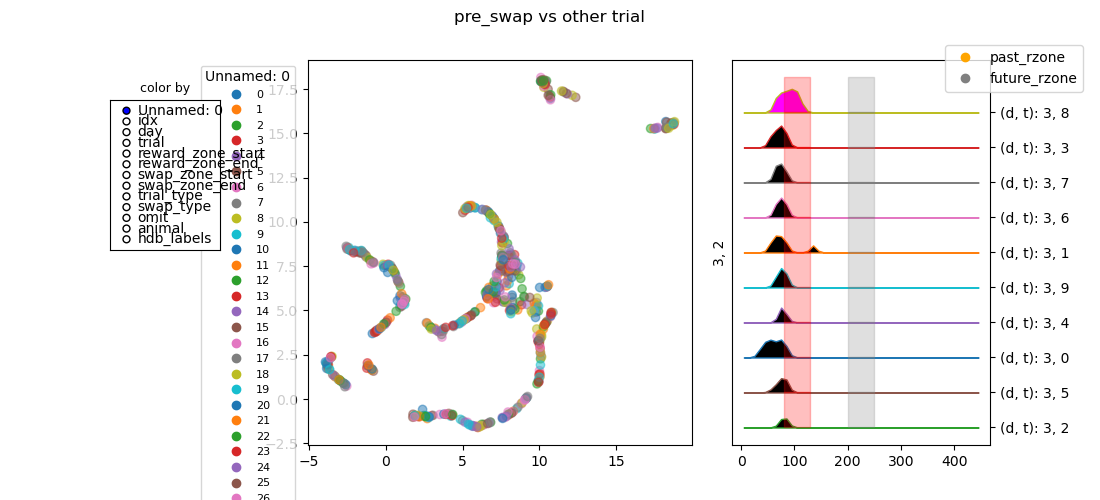

In [78]:
%matplotlib widget
import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector, ColorSelectorV2#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker

bin_centers = np.arange(5,455,10)

display_slicer = (trials_na_free.animal == 'GCAMP14')
# display_slicer = (trials_na_free.trial_type == 'post_swap')
# display_slicer = [True]*len(licks_na_free)

# feats = get_lick_features(licks_na_free[display_slicer], bin_centers, trials_na_free[display_slicer], norm = False)


features, sorted_meta, sorted_licks = generate_cross_day_features(licks_na_free[display_slicer], trials_na_free[display_slicer], bin_centers, norm = True)
feats = features[[c for c in features.columns if not c in ['at_zone', 'n_licks']]]
feats_norm = hellinger(feats)
reducer = umap.UMAP(n_neighbors=20, min_dist=0.2)

transform = reducer.fit_transform(feats)


# lick_pca = skd.PCA()
# transform = lick_pca.fit_transform(feats[:,1:])

new_labels = hdbscan.HDBSCAN(
    min_samples=3,
    min_cluster_size=3,

).fit_predict(transform)


metadata = sorted_meta.copy()
metadata['hdb_labels'] = new_labels


scatter_meta = metadata
scatter_data = transform
linker = TrialPlotLinker(metadata)
raster_data = sorted_licks

fig = plt.figure(figsize = (11,5))
fig.suptitle('pre_swap vs other trial')
axes_dict = fig.subplot_mosaic([['lick_umap', 'lick_umap', 'lick_raster'],
                                    ['lick_umap','lick_umap', 'lick_raster'],
                                    ],
                                height_ratios = [3.0,2.0],
                                width_ratios = [2.0,2.0,3])

ax_umap= axes_dict['lick_umap']




scatter_1 = ax_umap.scatter(scatter_data[:,0], scatter_data[:,1], alpha = 0.5, label = 'preswap')

ax_umap.legend()


add_hover(scatter_1, scatter_meta)
color_selector = ColorSelectorV2(scatter_1,scatter_meta)

sel = add_selectors(scatter_1, linker, scatter_meta)


umap_view = ppf.ScatterView(data = transform, meta = scatter_meta, plt_obj = scatter_1)


lick_ax = axes_dict['lick_raster']
lick_ax.tick_params(right=True, labelright=True, left=False, labelleft=False)

raster_view = ppf.LickRasterView(raster_data, bin_centers, scatter_meta, lick_ax)
raster_view.link_colormaps(color_selector.get_color_linker(), )
raster_view.sort_by({'hdb_labels':'descending', 'reward_zone_start':'descending','day':'descending', 'trial':'ascending'})
color_selector.add_after_recolor_call(raster_view.update_linked_colors)

linker.add_views([umap_view, raster_view]) 
# raster_view.update(start_idx)
# umap_view.update(start_idx)


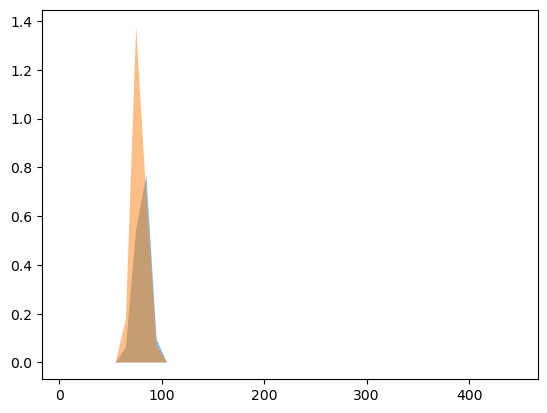

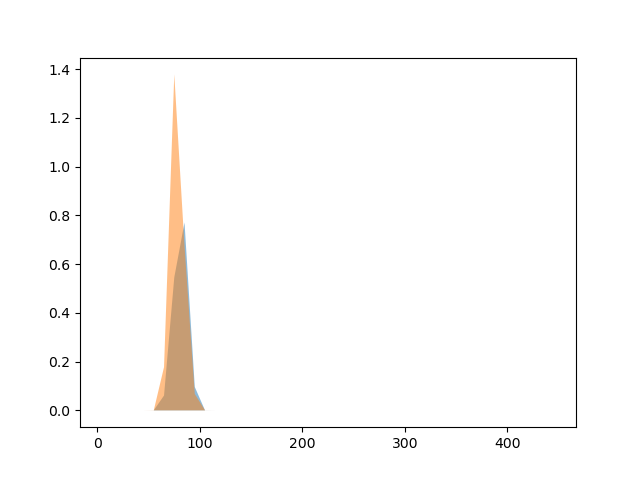

In [59]:
fig, ax =plt.subplots()
ax.fill_between(x = bin_centers, y1 = [0]*len(bin_centers), y2 = licks_na_free[(trials_na_free.animal=='GCAMP14')&(trials_na_free.day == 3) & (trials_na_free.trial == 26)][0], alpha = 0.5)
ax.fill_between(x = bin_centers, y1 = [0]*len(bin_centers), y2 = licks_na_free[(trials_na_free.animal=='GCAMP14')&(trials_na_free.day == 3) & (trials_na_free.trial == 4)][0], alpha = 0.5)
fig

In [60]:
features.values/features.n_licks[:,np.newaxis]

/tmp/ipykernel_3962018/168017662.py:1: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  features.values/features.n_licks[:,np.newaxis]


array([[1.00000000e+00, 1.44379697e-01, 0.00000000e+00, 0.00000000e+00,
        8.45722037e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 9.89826651e-03, 0.00000000e+00],
       [1.00000000e+00, 1.85706351e-01, 0.00000000e+00, 0.00000000e+00,
        6.70400043e-01, 4.25043326e-05, 0.00000000e+00, 1.43851101e-01,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 5.23134433e-01, 0.00000000e+00, 0.00000000e+00,
        4.76865567e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 2.36548640e-01, 0.00000000e+00, 0.00000000e+00,
        7.63451360e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 3.22387255e-01, 0.00000000e+00, 0.00000000e+00,
        6.77612745e-01, 0.00000000e+00, 0.00000000e+00, 0.00

In [79]:
features.loc[sorted_meta.trial.isin([26, 4]).values]

,n_licks,at_zone,at_zone_other,at_zone_third_zone,anticipatory_zone,anticipatory_zone_other,anticipatory_zone_third_zone,after_zone,after_zone_other,after_zone_third_zone,start,end
4,2.296296,0.322387,0.000000,0.0,0.677613,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
26,1.473868,0.588326,0.000000,0.0,0.411674,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
4,4.616110,0.258723,0.000000,0.0,0.452752,0.024913,0.0,0.263613,0.000000,0.0,0.0,0.0
26,1.517241,0.893285,0.000000,0.0,0.106715,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
4,2.890282,0.472700,0.000000,0.0,0.527300,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
26,2.214286,0.538060,0.000000,0.0,0.461940,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
4,2.066176,0.465010,0.000000,0.0,0.534990,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
26,1.250000,0.893285,0.000000,0.0,0.106715,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
4,2.131868,0.418910,0.000000,0.0,0.581090,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
26,4.247067,0.211378,0.000000,0.0,0.788622,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0


In [ ]:
ex_licks = licks_na_free[(trials_na_free.animal=='GCAMP14')&(trials_na_free.day == 3) & (trials_na_free.trial.isin([26,32]))]
ex_trials = trials_na_free[(trials_na_free.animal=='GCAMP14')&(trials_na_free.day == 3) & (trials_na_free.trial.isin([26,32]))]

dz = DayZones(ex_trials)

In [ ]:
get_licks_from_zone_object(ex_licks, dz.post_zone, bin_centers)

In [ ]:
get_licks_from_zone_object(ex_licks, dz.pre_zone, bin_centers)

In [ ]:
get_licks_at_location(ex_licks, dz.pre_zone.rzone, bin_centers)['licks'].sum(axis = 1)

In [ ]:
sorted_meta.loc[sorted_meta.trial.isin([26, 31]).values]

In [ ]:
pre_zone_licks = get_licks_from_zone_object(ex_licks, dz.pre_zone, bin_centers)
post_zone_licks = get_licks_from_zone_object(ex_licks, dz.post_zone, bin_centers)

In [ ]:
feat = np.zeros_like(pre_zone_licks['at_zone'])
feat[dz.pre_trials] = post_zone_licks['at_zone'][dz.pre_trials]
feat[dz.post_trials] = pre_zone_licks['at_zone'][dz.post_trials]

In [ ]:
pre_zone_licks['at_zone']

In [ ]:
post_zone_licks['at_zone']

In [ ]:
dz = DayZones(trials_na_free[display_slicer])

In [ ]:
dz.pre_zone

In [ ]:
fig, ax = plt.subplots()
non_zero = (feats.values[:,1:]>0).sum(axis=1)
ax.hist(9 - non_zero , bins = 'auto')

In [ ]:
pct_total = [sum(lick_pca.explained_variance_[:i+1]/lick_pca.explained_variance_.sum()) for i in range(transform.shape[1])]
lick_pca.explained_variance_/lick_pca.explained_variance_.sum()
fig, ax = plt.subplots()
ax.plot(pct_total, 'o')

In [ ]:
fig, axs = plt.subplots(ncols = 5, nrows = 5, figsize = (18,18))
scatters = []
for i, n_neighbor in enumerate(np.arange(3, 15, 3)):
    for j, min_dist in enumerate(np.arange(0, 0.99, 0.99/5)):
        
        reducer = umap.UMAP(n_neighbors=int(n_neighbor), min_dist=min_dist)
        

        embedding = reducer.fit_transform(feats[:,1:])


        scatters += [axs[i,j].scatter(embedding[:,0], embedding[:,1])]
        axs[i,j].set_title(f'nn: {int(n_neighbor)}, md: {min_dist:.3f}')
        
color_selector = ColorSelectorV2(scatters[0],scatter_meta)
color_selector.add_additional_scatter_objects(scatters[1:])

In [ ]:
features.columns

In [ ]:
fig, axs = plt.subplots(3,3, figsize = (10,10))
for ax, col in zip(axs.ravel(), features.columns):
    ax.hist(features[col], bins = 'auto')
    ax.set_title(col)

In [ ]:
fig, ax = plt.subplots()
ax.scatter(feats[:,1], feats[:,5])

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)
scatter = ax.scatter(
    transform[:, 0],
    transform[:, 1],
    transform[:, 2],
    c=scatter_meta.reward_zone_start,
   
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    scatter_meta.reward_zone_start.unique().tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

In [ ]:
%matplotlib widget
import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker

bin_centers = np.arange(5,455,10)

display_slicer = trials_na_free.animal == 'GCAMP12'

metadata = trials_na_free.loc[display_slicer]
scatter_meta = metadata
scatter_data = embedding[display_slicer]
linker = TrialPlotLinker(metadata)

fig = plt.figure(figsize = (11,5))
fig.suptitle('pre_swap vs other trial')
axes_dict = fig.subplot_mosaic([['lick_umap', 'lick_umap', 'lick_raster'],
                                    ['lick_umap','lick_umap', 'lick_raster'],
                                    ],
                                height_ratios = [3.0,2.0],
                                width_ratios = [2.0,2.0,3])

ax_umap= axes_dict['lick_umap']




scatter_1 = ax_umap.scatter(scatter_data[:,0], scatter_data[:,1], alpha = 0.5, label = 'preswap')

ax_umap.legend()


add_hover(scatter_1, scatter_meta)
color_selector = ColorSelector(scatter_1,scatter_meta)

sel = add_selectors(scatter_1, linker, scatter_meta)


umap_view = ppf.ScatterView(data = embedding, meta = scatter_meta, plt_obj = scatter_1)


lick_ax = axes_dict['lick_raster']
lick_ax.tick_params(right=True, labelright=True, left=False, labelleft=False)

raster_view = ppf.LickRasterView(licks_na_free[display_slicer], bin_centers, scatter_meta, lick_ax)
raster_view.link_colormaps(color_selector.get_color_linker(), )
raster_view.sort_by({'hdb_labels':'descending', 'day':'descending', 'trial':'descending'})
color_selector.add_after_recolor_call(raster_view.update_linked_colors)

linker.add_views([umap_view, raster_view]) 
# raster_view.update(start_idx)
# umap_view.update(start_idx)


In [ ]:
animal = 'GCAMP15'
day = 10
label = 166
start_idx =trials_na_free.loc[(trials_na_free.animal == animal)&(trials_na_free.day==day)&(trials_na_free.hdb_labels == label), 'idx'].values

raster_view.update(start_idx)
umap_view.update(start_idx)

In [ ]:
def sum_outliers(animal_dict):
    tot = 0
    for d in animal_dict.keys():
        tot += len(animal_dict[d].keys())
    return tot

sum_outliers(outliers['GCAMP11'])

In [ ]:
ppf = importlib.reload(ppf)
def make_outlier_rasters(animal, outlier_dict, data, metadata_df):
    bin_centers = np.arange(5,455,10)
    num_plots = sum_outliers(outlier_dict[animal])

    cols = 4
    rows = int(np.ceil(num_plots/cols))

    fig, axs = plt.subplots(ncols = cols, nrows = rows, figsize = (10, 3*rows))

    loc = 0

    for d, labels in outlier_dict[animal].items():
        for l, df in labels.items():
            dat = data[metadata_df['idx'].isin(df.idx.values)]
            v = ppf.LickRasterView(dat, bin_centers, df, axs.ravel()[loc])
            loc+=1
            v.plt_obj.set_title(f'label: {l} d: {d}')
            
            v.plt_obj.set_yticklabels([f"tr {row[1]}" for row in df[['day','trial']].values], rotation = 90)
    
    fig.suptitle(animal)
            


In [ ]:
ppf = importlib.reload(ppf)
def plot_raster_from_licks( data, metadata_df, ax, starting_selection = -1):
    bin_centers = np.arange(5,455,10)



    v = ppf.LickRasterView(data, bin_centers, metadata_df, ax, starting_selection = starting_selection)

    
    
    


In [ ]:
make_outlier_rasters('GCAMP14', outliers, licks_na_free, trials_na_free)

In [ ]:
for animal in outliers.keys():
    make_outlier_rasters(animal, outliers, licks_na_free, trials_na_free)

In [ ]:
f.close()

In [ ]:
import h5py
file_name = '/data/dave/sosa_data_h5/hdf5_conversion'

f= h5py.File(file_name, "r")

In [ ]:
f['GCAMP13'].keys()

In [ ]:
def recreate_trial_meta_df(hdf5_group):
    data_dict = {key:hdf5_group[key][:] for key in hdf5_group.keys()}
    for k,vals in data_dict.items():
        if vals.dtype == np.dtypes.ObjectDType:
            data_dict[k] = np.asarray([v.decode() for v in vals])
    return pd.DataFrame.from_dict(data_dict)
        

In [ ]:
f.keys()

In [ ]:
animal = 'GCAMP19'
day = '14' 
df = recreate_trial_meta_df(f[animal][day]['trial_metadata'])
fig, ax = plt.subplots()
plot_raster_from_licks(f[animal][day]['lick_data']['smoothed_licks'][[i for i in range(80)]], df.iloc[[i for i in range(80)]], ax)
# plot_raster_from_licks(f[animal][day]['lick_data']['smoothed_licks'][[9,10,29,30,34,35,55]], df.iloc[[9,10,29,30,34,35,55]], ax)


In [ ]:
trials_na_free

In [ ]:
def add_default_rzone_lines(ax, color = 'white', alpha = 0.5):
    for loc in [80, 200, 320]:
        ax.vlines(x = [loc], ymin=0, ymax=449, color = color, alpha = alpha, linestyles= '--')
        ax.hlines(y = [loc], xmin = 0, xmax = 449, color = color, alpha = alpha,  linestyles= '--')



In [ ]:
trial_1 = 21
trial_2 = 64

# trial_1 = 'mean_pre'
# pv1 = f['GCAMP13']['14']['neural_events_trial_matrix'][5:25].mean(axis = 0)
pv1 = f[animal][day]['neural_events_trial_matrix'][trial_1,:]
pv2 = f[animal][day]['neural_events_trial_matrix'][trial_2,:]

corr_mats, corr_labels = pf.correlate_two_pop_vectors(pv1, pv2, pv1_name=f'trial {trial_1}', pv2_name=f'trial {trial_2}')

fig = plt.figure(figsize = (9,6))
fig.suptitle(f"{animal} day {day}")
axes_dict = fig.subplot_mosaic([['corr_mat', 'pearsons_diag', 'lick_raster'],
                                    ['corr_mat', 'speed', 'lick_raster'],
                                    ],
                                height_ratios = [1.0,1.0],
                                width_ratios = [1.0,1.0, 1.0])

r_zone1 = df.iloc[0]['reward_zone_start']
r_zone2 = df.iloc[trial_2]['reward_zone_start']

clim = (min([m.min() for m in corr_mats]), max([m.max() for m in corr_mats]))

corr_mat = corr_mats[-1]


im = axes_dict['corr_mat'].imshow(corr_mat, clim = clim)
add_default_rzone_lines(axes_dict['corr_mat'], alpha = 0.3)

axes_dict['corr_mat'].vlines(x = [r_zone1], ymin=0, ymax=449, color = 'white', linestyles= '--')
axes_dict['corr_mat'].hlines(y = [r_zone1], xmin = 0, xmax = 449, color = 'white', linestyles= '--')

axes_dict['corr_mat'].vlines(x = [r_zone2], ymin = 0, ymax = 449, color = 'orange', linestyles= '--')
axes_dict['corr_mat'].hlines(y = [r_zone2], xmin = 0, xmax = 449, color = 'orange', linestyles= '--')


axes_dict['corr_mat'].set_title(corr_labels[-1])

axes_dict['pearsons_diag'].plot(np.diag(corr_mats[-1]))
axes_dict['pearsons_diag'].set_ylim((0,1))
for st in [80, 200, 320]:
    axes_dict['pearsons_diag'].axvspan(st, st+50, color = 'red', alpha = 0.2)
    axes_dict['speed'].axvspan(st, st+50, color = 'red', alpha = 0.2)

plot_raster_from_licks(f[animal][day]['lick_data']['smoothed_licks'][[trial_1, trial_2]], df.iloc[[trial_1, trial_2]], axes_dict['lick_raster'])
axes_dict['lick_raster'].tick_params(right=True, labelright=True, left=False, labelleft=False)
axes_dict['pearsons_diag'].set_title('pearsons value\non diagonal')
fig.colorbar(im, ax=axes_dict['corr_mat'], location = 'bottom')

speeds = f[animal][day]['speed']['speed'][[trial_1, trial_2]]
speed_bins = f[animal][day]['speed']['bin_center'][:]
for trial, speed in zip([trial_1, trial_2], speeds):
    axes_dict['speed'].plot(speed_bins, speed, label = trial)
axes_dict['speed'].legend()
axes_dict['speed'].set_title('speed')

In [ ]:
trials_na_free.loc[(trials_na_free.animal == 'GCAMP12') & (trials_na_free.day == 10)]['trial'].values

In [ ]:
(day_meta.trial_type == 'pre_swap')&(day_meta.omit == False)

In [ ]:
f[animal][day]['neural_events_trial_matrix'][:].shape

In [ ]:
df

In [ ]:
day = '14' 
# day_meta = trials_na_free.loc[(trials_na_free.animal == animal) & (trials_na_free.day == int(day))]
# day_slicer_pre = (day_meta.trial_type == 'pre_swap')&(day_meta.omit == False)
# day_slicer_post = (day_meta.trial_type == 'post_swap')&(day_meta.omit == False)

day_meta = df
day_slicer_pre = (day_meta.trial_type == 'pre_swap')&(day_meta.omit == False)
day_slicer_post = (day_meta.trial_type == 'post_swap')&(day_meta.omit == False)

pre = np.mean(f[animal][day]['neural_events_trial_matrix'][day_slicer_pre,:], axis= 0)
post = np.mean(f[animal][day]['neural_events_trial_matrix'][day_slicer_post,:], axis=0)

fig, axs = plt.subplots(ncols = 4, nrows = 20, figsize = (9, 4*15), layout = 'constrained')
fig.suptitle(f'{animal} {day}\ntrial vs mean pre-swap (1:30)')
for i, z in enumerate(zip(axs.ravel(), f[animal][day]['neural_events_trial_matrix'][:])):

    ax, pv = z

    corr_mats, _ = pf.correlate_two_pop_vectors(pre, pv, pv1_name=f'trial {trial_1}', pv2_name=f'trial {trial_2}')

    r_zone1 = day_meta.iloc[0]['reward_zone_start']
    r_zone2 = day_meta.iloc[-1]['reward_zone_start']
    trial_type = day_meta.iloc[i]['trial_type']
    clim = (0,1)

    corr_mat = corr_mats[-1]


    im = ax.imshow(corr_mat, clim = clim)
    add_default_rzone_lines(ax, alpha = 0.1)

    ax.vlines(x = [r_zone1], ymin=0, ymax=449, color = 'gray', linestyles= '--', alpha = 0.75)
    ax.hlines(y = [r_zone1], xmin = 0, xmax = 449, color = 'gray', linestyles= '--', alpha = 0.75)

    ax.vlines(x = [r_zone2], ymin = 0, ymax = 449, color = 'orange', linestyles= '--', alpha = 0.5)
    ax.hlines(y = [r_zone2], xmin = 0, xmax = 449, color = 'orange', linestyles= '--', alpha = 0.5)


    if day_meta.iloc[i]['omit'] == True:
        ax.set_title(f'trial {i+1}, omission', color = 'magenta')
    elif trial_type == 'pre_swap':

        ax.set_title(f'trial {i+1}')
    else:
        ax.set_title(f'trial {i+1}', color = 'orange')
fig.savefig(f'{animal} {day}\ntrial vs mean pre-swap (1>30).png')

fig, axs = plt.subplots(ncols = 4, nrows = 20, figsize = (9, 4*15), layout = 'constrained')
fig.suptitle(f'{animal} {day}\ntrial vs mean post-swap (31:80)')

for i, z in enumerate(zip(axs.ravel(), f[animal][day]['neural_events_trial_matrix'][:])):

    ax, pv = z

    corr_mats, _ = pf.correlate_two_pop_vectors(post, pv, pv1_name=f'trial {trial_1}', pv2_name=f'trial {trial_2}')


    clim = (0,1)

    corr_mat = corr_mats[-1]
    trial_type = day_meta.iloc[i]['trial_type']


    im = ax.imshow(corr_mat, clim = clim)
    add_default_rzone_lines(ax, alpha = 0.1)

    ax.vlines(x = [r_zone1], ymin=0, ymax=449, color = 'gray', linestyles= '--', alpha = 0.75)
    ax.hlines(y = [r_zone1], xmin = 0, xmax = 449, color = 'gray', linestyles= '--', alpha = 0.75)

    ax.vlines(x = [r_zone2], ymin = 0, ymax = 449, color = 'orange', linestyles= '--', alpha = 0.5)
    ax.hlines(y = [r_zone2], xmin = 0, xmax = 449, color = 'orange', linestyles= '--', alpha = 0.5)


    if day_meta.iloc[i]['omit'] == True:
        ax.set_title(f'trial {i+1}, omission', color = 'magenta')
    elif trial_type == 'pre_swap':

        ax.set_title(f'trial {i+1}')
    else:
        ax.set_title(f'trial {i+1}', color = 'orange')
fig.savefig(f'{animal} {day}\ntrial vs mean post-swap (31>80).png')
    

In [ ]:
fig.tight_layout()

In [ ]:
dvs = np.diff(speeds)
fig, ax = plt.subplots()

for trial, speed in zip([trial_1, trial_2], dvs):
    ax.plot(speed_bins[1:], speed, label = trial)

for st in [80, 200, 320]:
    ax.axvspan(st, st+50, color = 'red', alpha = 0.15)

twin = ax.twinx()
twin.plot(np.diag(corr_mats[-1]), color = 'lightgreen')
ax.axvline(x = 286, color = 'black')
ax.axhline(y = 0, color = 'gray', linestyle = '--')


In [ ]:
dvs = np.diff(speeds)
fig, ax = plt.subplots()

# for trial, speed in zip([trial_1, trial_2], speeds):
#     ax.plot(speed_bins, speed, label = trial)
ax.plot(speed_bins, speeds[0] - speeds[1])
for st in [80, 200, 320]:
    ax.axvspan(st, st+50, color = 'red', alpha = 0.2)

twin = ax.twinx()
twin.plot(np.diag(corr_mats[-1]), color = 'lime')
ax.axvline(x = 286, color = 'black')
ax.axhline(y = 0, color = 'gray', linestyle = '--')

In [ ]:
df.head()

In [ ]:
fig, ax = plt.subplots()
cell = 10
ax.plot(f[animal][day]['neural_events_trial_matrix'][trial_1,:,cell])
ax.plot(f[animal][day]['neural_events_trial_matrix'][trial_2,:,cell])

In [ ]:
import matplotlib.cm as cm
fig, ax = plt.subplots()
cell = 3
trials = np.asarray(range(15,50,1))
cmap = np.concatenate([cm.PuRd(np.linspace(0.25, 1, sum(trials<30) )), cm.BuGn(np.linspace(0.25, 1, sum(trials>=30) ))])
for i, trial in enumerate(trials):
    ax.plot(f[animal][day]['neural_events_trial_matrix'][trial,:,cell], color = cmap[i])


In [ ]:
f.close()